In [9]:
# Sports Player Recommender

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics import silhouette_score

# Step 1: Load Dataset
file_path = "IPL_Data.csv"  # Ensure this is the correct path
df = pd.read_csv(file_path)

df.head()

,Player,AGE,Paying_Role,Mat,Inns,Runs,SR,Avg,4s,6s,B_Inns,B_Balls,B_Runs,B_Wkts,B_Econ,B_SR
0,Ruturaj Gaikwad,26,Batting,36,36.0,1207.0,130.35,37.72,113.0,43.0,0.0,0.0,0.0,0.0,0.00,0.00
1,Shivam Dube,29,All rounder,35,33.0,688.0,133.33,24.57,46.0,38.0,13.0,106.0,166.0,4.0,9.40,26.50
2,Ambati Rayudu,37,Batting,188,175.0,4190.0,127.12,28.90,349.0,164.0,0.0,0.0,0.0,0.0,0.00,0.00
3,Devon Conway,31,Batting,7,7.0,252.0,145.66,42.00,22.0,12.0,0.0,0.0,0.0,0.0,0.00,0.00
4,Moeen Ali,35,All rounder,44,42.0,910.0,143.99,23.33,76.0,53.0,37.0,554.0,627.0,24.0,6.79,23.08


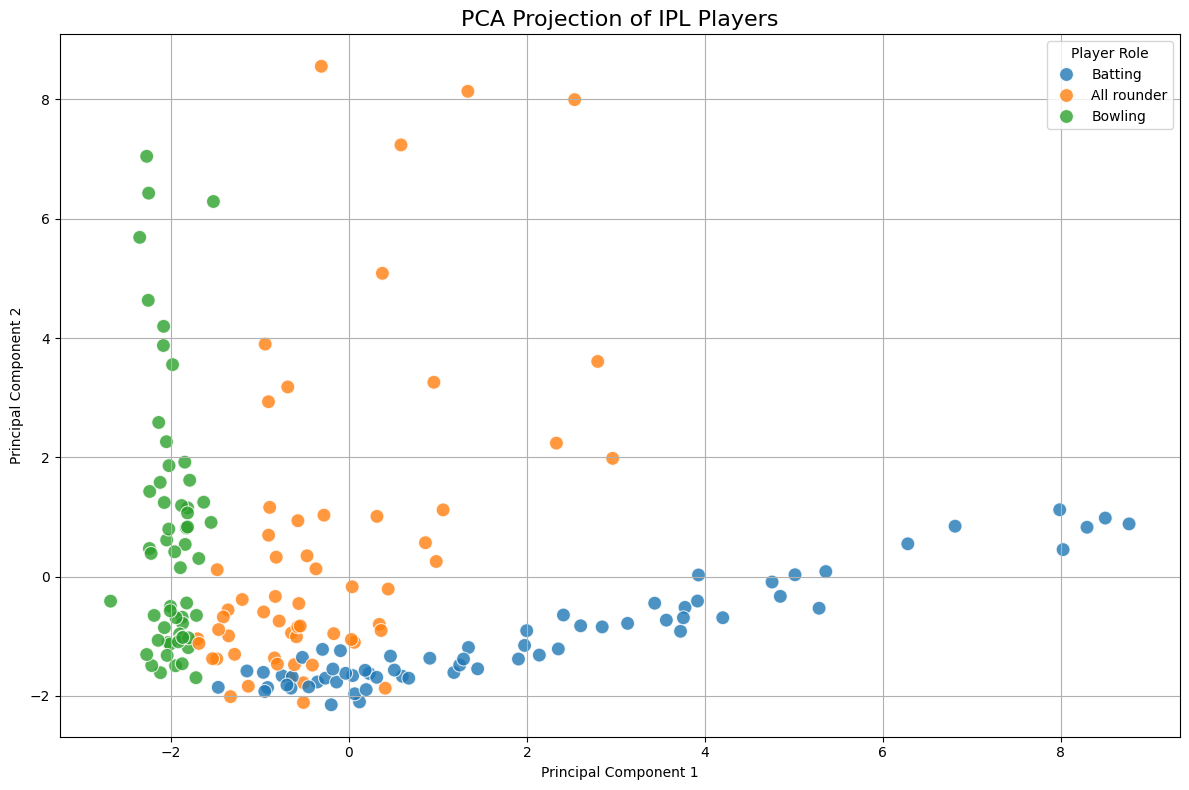

In [ ]:
# Step 2: Select Relevant Features for PCA & Scoring
features = [
    'AGE', 'Mat', 'Inns', 'Runs', 'SR', 'Avg', '4s', '6s',
    'B_Inns', 'B_Balls', 'B_Runs', 'B_Wkts', 'B_Econ', 'B_SR'
]
X = df[features]

# Step 3: Standardize the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 4: Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 5: Add PCA Results to DataFrame
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_pca['Player'] = df['Player']
df_pca['Role'] = df['Paying_Role']
df_pca['Index'] = df.index

# Step 6: Visualization of PCA
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Role', s=100, alpha=0.8)
plt.title("PCA Projection of IPL Players", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.legend(title="Player Role")
plt.tight_layout()
plt.show()

In [10]:
# Step 7: Fantasy Team Builder with Interactive Input
# Define a custom performance score (simplified)
def compute_score(row):
    batting_score = row['Runs'] * 0.03 + row['SR'] * 0.1 + row['Avg'] * 0.2 + row['4s'] * 0.05 + row['6s'] * 0.1
    bowling_score = row['B_Wkts'] * 2 + (6 - row['B_Econ']) * 1 + (25 - row['B_SR']) * 0.5
    return batting_score + bowling_score

# Apply the scoring function
df['Score'] = df.apply(compute_score, axis=1)

# Get user input for team composition
try:
    num_batsmen = int(input("Enter number of batsmen: "))
    num_bowlers = int(input("Enter number of bowlers: "))
    num_allrounders = int(input("Enter number of all-rounders: "))
    num_wicketkeepers = int(input("Enter number of wicketkeepers: "))
except ValueError:
    print("Invalid input! Using default configuration: 4 Batsmen, 3 Bowlers, 3 All-rounders, 1 WK")
    num_batsmen, num_bowlers, num_allrounders, num_wicketkeepers = 4, 3, 3, 1

# Build team based on input
team = []
team += df[df['Paying_Role'] == 'Batting'].sort_values(by='Score', ascending=False).head(num_batsmen).to_dict('records')
team += df[df['Paying_Role'] == 'Bowling'].sort_values(by='Score', ascending=False).head(num_bowlers).to_dict('records')
team += df[df['Paying_Role'] == 'All rounder'].sort_values(by='Score', ascending=False).head(num_allrounders).to_dict('records')
team += df[df['Paying_Role'].str.lower().str.contains('wk')].sort_values(by='Score', ascending=False).head(num_wicketkeepers).to_dict('records')

# Step 8: Display Final Fantasy Team
print("\n\nRecommended Fantasy XI:\n")
for player in team:
    print(f"{player['Player']} - {player['Paying_Role']} | Score: {player['Score']:.2f}")



Enter number of batsmen: 2
Enter number of bowlers: 4
Enter number of all-rounders: 4
Enter number of wicketkeepers: 0


Recommended Fantasy XI:

Virat Kohli - Batting | Score: 288.07
Shikhar Dhawan - Batting | Score: 274.05
Yuzvendra Chahal - Bowling | Score: 334.29
Bhuvneshwar Kumar - Bowling | Score: 308.61
Jasprit Bumrah - Bowling | Score: 291.65
Umesh Yadav - Bowling | Score: 277.17
Dwayne Bravo - All rounder | Score: 444.52
Ravindra Jadeja - All rounder | Score: 374.00
Sunil Narine - All rounder | Score: 366.39
Ravichandran Ashwin - All rounder | Score: 351.62


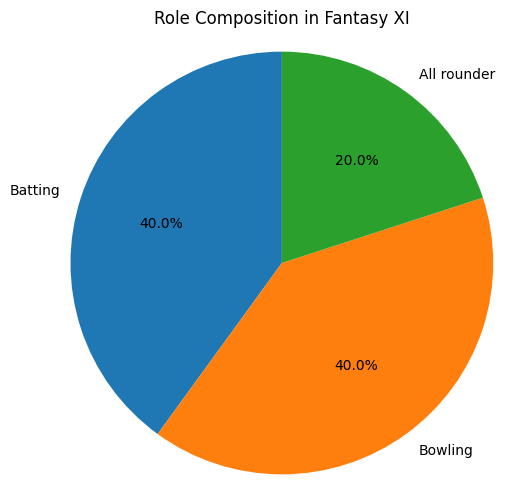

In [ ]:
# Role distribution pie chart
role_counts = team_df['Paying_Role'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(role_counts, labels=role_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Role Composition in Fantasy XI")
plt.axis('equal')
plt.show()

In [ ]:
# Step 9: Similar Player Recommender using PCA space
def recommend_similar_players(player_name, df_pca, top_n=5):
    if player_name not in df_pca['Player'].values:
        return f"Player '{player_name}' not found in the dataset."

    player_vector = df_pca[df_pca['Player'] == player_name][['PC1', 'PC2']].values
    all_vectors = df_pca[['PC1', 'PC2']].values
    distances = euclidean_distances(player_vector, all_vectors)[0]

    df_pca['Distance'] = distances
    recommendations = df_pca[df_pca['Player'] != player_name].sort_values(by='Distance').head(top_n)
    return recommendations[['Player', 'Role', 'Distance']]

# Step 10: Test similar player recommender
example_player = input("\nEnter a player name to find similar players: ")
similar = recommend_similar_players(example_player, df_pca)

print(f"\nTop players similar to {example_player}:")
print(similar.to_string(index=False) if isinstance(similar, pd.DataFrame) else similar)


Enter a player name to find similar players: Virat Kohli

Top players similar to Virat Kohli:
        Player    Role  Distance
  Rohit Sharma Batting  0.284849
Shikhar Dhawan Batting  0.475823
      MS Dhoni Batting  0.814622
  David Warner Batting  0.857414
Dinesh Karthik Batting  1.955295


In [ ]:
# Step 11: Evaluate Fantasy Team Performance
team_df = pd.DataFrame(team)
print("\nTeam Performance Summary:")
print(team_df[['Runs', 'SR', 'Avg', 'B_Wkts', 'B_Econ', 'Score']].mean())

# Step 12: Evaluate PCA Cluster Quality
try:
    sil_score = silhouette_score(X_scaled, df['Paying_Role'])
    print(f"\nSilhouette Score for PCA clustering by role: {sil_score:.2f}")
except Exception as e:
    print("\nSilhouette score evaluation failed:", e)


Team Performance Summary:
Runs      2869.2000
SR          82.3280
Avg         20.6370
B_Wkts      91.5000
B_Econ       4.6680
Score      312.4022
dtype: float64

Silhouette Score for PCA clustering by role: 0.18
